# Optional Lab - Softmax Function
在本实验中，我们将探究softmax函数。在解决多分类问题时，该函数在Softmax回归和神经网络中都会用到。

<center>  <img  src="../work/images/C2_W2_Softmax_Header.PNG" width="600" />  <center/>

  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from IPython.display import display, Markdown, Latex
from sklearn.datasets import make_blobs
%matplotlib widget
from matplotlib.widgets import Slider
from lab_utils_common import dlc
from lab_utils_softmax import plt_softmax
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

> **注意**：通常在本课程中，笔记本使用从0开始计数到N - 1结束的惯例，即 $\sum_{i=0}^{N-1}$，而课堂讲授则从1开始计数到N结束，即 $\sum_{i=1}^{N}$。这是因为代码通常会从0开始迭代，而在课堂讲授中，从1数到N会使公式更简洁明了。本笔记本中的公式比一般实验要多，因此将打破这一惯例，采用从1数到N的计数方式。 

##  softmax函数
在softmax回归和具有softmax输出的神经网络中，都会生成N个输出，并选择其中一个输出作为预测类别。在这两种情况下，线性函数会生成一个向量 $\mathbf{z}$，并将其应用于softmax函数。softmax函数将 $\mathbf{z}$ 转换为如下所述的概率分布。应用softmax后，每个输出都将介于0和1之间，且所有输出之和为1，因此它们可以被解释为概率。输入越大，对应的输出概率就越大。 
<center>  <img  src="../work/images/C2_W2_SoftmaxReg_NN.png" width="600" />  

softmax函数可以写成：
$$a_j = \frac{e^{z_j}}{ \sum_{k=1}^{N}{e^{z_k} }} \tag{1}$$

输出 $\mathbf{a}$ 是一个长度为N的向量，因此对于softmax回归，你也可以写成：

\begin{align}
\mathbf{a}(x) =
\begin{bmatrix}
P(y = 1 | \mathbf{x}; \mathbf{w},b) \\
\vdots \\
P(y = N | \mathbf{x}; \mathbf{w},b)
\end{bmatrix}
=
\frac{1}{ \sum_{k=1}^{N}{e^{z_k} }}
\begin{bmatrix}
e^{z_1} \\
\vdots \\
e^{z_{N}} \\
\end{bmatrix} \tag{2}
\end{align}


这表明输出是一个概率向量。第一个元素是在给定输入$\mathbf{x}$以及参数$\mathbf{w}$和$\mathbf{b}$的情况下，输入属于第1类别的概率。   
我们来创建一个NumPy实现：

In [2]:
def my_softmax(z):
    ez = np.exp(z)              #element-wise exponenial
    sm = ez/np.sum(ez)
    return(sm)

在下方，使用滑块改变`z`输入的值。

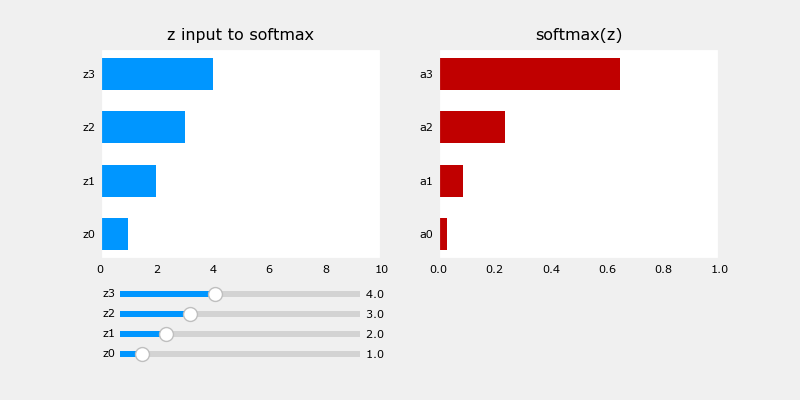

In [3]:
plt.close("all")
plt_softmax(my_softmax)

当你改变上述z值时，有几点需要注意：
* softmax分子中的指数会放大数值上的微小差异
* 输出值总和为1
* softmax涵盖所有输出。例如，`z0`的变化会改变`a0` - `a3`的值。将此与其他激活函数（如ReLU或Sigmoid）进行比较，后者只有一个输入和一个输出。 

## Cost
<center> <img  src="../work/images/C2_W2_SoftMaxCost.png" width="400" />    <center/>

与Softmax相关的损失函数，即交叉熵损失，为：
\begin{equation}
  L(\mathbf{a},y)=\begin{cases}
    -log(a_1), & \text{if $y=1$}.\\
        &\vdots\\
     -log(a_N), & \text{if $y=N$}
  \end{cases} \tag{3}
\end{equation}

其中$y$是此示例的目标类别，$\mathbf{a}$是softmax函数的输出。特别地，$\mathbf{a}$中的值是总和为1的概率。
>**回顾**：在本课程中，损失（Loss）是针对单个示例而言，而代价（Cost）涵盖所有示例。
 

请注意上述公式（3）中，只有与目标对应的那一行对损失有贡献，其他行均为零。为了写出代价方程，我们需要一个 “指示函数”，当索引与目标匹配时该函数值为1，否则为0。 
    $$\mathbf{1}\{y == n\} = =\begin{cases}
    1, & \text{if $y==n$}.\\
    0, & \text{otherwise}.
  \end{cases}$$
现在cost为：
\begin{align}
J(\mathbf{w},b) = - \left[ \sum_{i=1}^{m} \sum_{j=1}^{N}  1\left\{y^{(i)} == j\right\} \log \frac{e^{z^{(i)}_j}}{\sum_{k=1}^N e^{z^{(i)}_k} }\right] \tag{4}
\end{align}

其中$m$是样本数量，$N$是输出数量。这是所有损失的平均值。


## Tensorflow
本实验将讨论在TensorFlow中实现softmax交叉熵损失的两种方法，即“直观”方法和“推荐”方法。前者最为直接，而后者在数值上更稳定。

我们首先创建一个数据集来训练一个多分类模型。

In [4]:
# make  dataset for example
centers = [[-5, 2], [-2, -2], [1, 2], [5, -2]]
X_train, y_train = make_blobs(n_samples=2000, centers=centers, cluster_std=1.0,random_state=30)

### *直观* 组织方式

以下模型在最后一个全连接层中使用softmax作为激活函数。   
损失函数在`compile`指令中单独指定。   

损失函数为`SparseCategoricalCrossentropy`，即上述(3)中描述的损失。在这个模型中，softmax运算发生在最后一层。损失函数接收softmax的输出，该输出是一个概率向量。 

In [5]:
model = Sequential(
    [ 
        Dense(25, activation = 'relu'),
        Dense(15, activation = 'relu'),
        Dense(4, activation = 'softmax')    # < softmax activation here
    ]
)
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(0.001),
)

model.fit(
    X_train,y_train,
    epochs=10
)
        

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 678us/step - loss: 0.8663 
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 620us/step - loss: 0.3662
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 610us/step - loss: 0.1857
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 601us/step - loss: 0.1106
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 600us/step - loss: 0.0797
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 604us/step - loss: 0.0645
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 672us/step - loss: 0.0555
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 637us/step - loss: 0.0498
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 611us/step - loss: 0.0452
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 649us/step - loss: 0.0418


由于softmax函数集成在输出层中，所以输出是一个概率向量。

In [6]:
p_nonpreferred = model.predict(X_train)
print(p_nonpreferred [:2])
print("largest value", np.max(p_nonpreferred), "smallest value", np.min(p_nonpreferred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 565us/step
[[1.15e-02 5.73e-03 9.68e-01 1.51e-02]
 [9.94e-01 6.26e-03 6.34e-05 1.16e-06]]
largest value 0.99999726 smallest value 2.1342547e-10


### 推荐 <img align="Right" src="../work/images/C2_W2_softmax_accurate.png"  style=" width:400px; padding: 10px 20px ; ">
回顾课堂内容，如果在训练过程中将softmax和损失结合起来，就可以得到更稳定、更准确的结果。这可以通过此处所示的 “首选” 结构来实现。


在理想的结构中，最后一层具有线性激活。由于历史原因，这种形式的输出被称为 *logits*。损失函数有一个额外的参数：`from_logits = True`。这告知损失函数，在损失计算中应包含softmax运算。这可以实现优化的算法。 

In [7]:
preferred_model = Sequential(
    [ 
        Dense(25, activation = 'relu'),
        Dense(15, activation = 'relu'),
        Dense(4, activation = 'linear')   #<-- Note
    ]
)
preferred_model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),  #<-- Note
    optimizer=tf.keras.optimizers.Adam(0.001),
)

preferred_model.fit(
    X_train,y_train,
    epochs=10
)
        

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 670us/step - loss: 1.0520 
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 621us/step - loss: 0.4870
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 576us/step - loss: 0.2161
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 614us/step - loss: 0.1177
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 590us/step - loss: 0.0820
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 600us/step - loss: 0.0654
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 612us/step - loss: 0.0557
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 607us/step - loss: 0.0504
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 601us/step - loss: 0.0457
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 592us/step - loss: 0.0418


#### 输出处理
请注意，在首选模型中，输出不是概率，而是可以从较大的负数到较大的正数取值。当进行需要概率的预测时，输出必须经过softmax函数处理。   
我们来看看首选模型的输出：

In [8]:
p_preferred = preferred_model.predict(X_train)
print(f"two example output vectors:\n {p_preferred[:2]}")
print("largest value", np.max(p_preferred), "smallest value", np.min(p_preferred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 589us/step
two example output vectors:
 [[-1.97 -2.25  5.49  1.74]
 [ 5.5   0.82 -2.35 -2.92]]
largest value 16.302883 smallest value -7.894254


输出预测结果并非概率！   
如果期望的输出是概率，那么输出应该通过[softmax](https://www.tensorflow.org/api_docs/python/tf/nn/softmax)进行处理。

In [9]:
sm_preferred = tf.nn.softmax(p_preferred).numpy()
print(f"two example output vectors:\n {sm_preferred[:2]}")
print("largest value", np.max(sm_preferred), "smallest value", np.min(sm_preferred))

two example output vectors:
 [[5.64e-04 4.24e-04 9.76e-01 2.30e-02]
 [9.90e-01 9.19e-03 3.89e-04 2.19e-04]]
largest value 1.0 smallest value 3.0996778e-11


要选择最有可能的类别，并不需要使用softmax函数。可以使用[np.argmax()](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html)来找到最大输出值的索引。

In [10]:
for i in range(5):
    print( f"{p_preferred[i]}, category: {np.argmax(p_preferred[i])}")

[-1.97 -2.25  5.49  1.74], category: 2
[ 5.5   0.82 -2.35 -2.92], category: 0
[ 4.09  1.07 -1.87 -2.42], category: 0
[-0.79  4.83 -1.25 -1.6 ], category: 1
[ 0.07 -3.3   5.65  0.15], category: 2


## 稀疏类别交叉熵（SparseCategorialCrossentropy）或类别交叉熵（CategoricalCrossEntropy）
TensorFlow 对于目标值有两种可能的格式，损失函数的选择决定了预期使用哪种格式。
- 稀疏类别交叉熵：期望目标值是对应索引的整数。例如，如果有10个可能的目标值，y 的取值范围将在0到9之间。
- 类别交叉熵：期望示例的目标值是独热编码，即目标索引处的值为1，而其他 N - 1 个条目为0。例如，对于有10个可能目标值且目标值为2的情况，编码为[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]。 


## 恭喜！
在本实验中，你
- 对softmax函数及其在softmax回归和神经网络的softmax激活中的应用更加熟悉。
- 学习了TensorFlow中推荐的模型构建方法：
    - 最后一层不使用激活函数（与线性激活相同）
    - 使用稀疏分类交叉熵损失函数
    - 使用`from_logits=True`
- 认识到与ReLU和Sigmoid不同，softmax函数涵盖多个输出。

## 数值稳定性（选读）
本节讨论一些用于提高数值稳定性的方法。这部分内容供感兴趣的读者阅读，并非必读。 

###  Softmax函数的数值稳定性
Softmax函数的输入是线性层的输出$z_j = \mathbf{w_j} \cdot \mathbf{x}^{(i)}+b$ 。这些值可能会很大。Softmax算法的第一步是计算$e^{z_j}$。如果这个值变得太大，可能会导致溢出错误。试着运行下面的代码单元格： 

In [11]:
for z in [500,600,700,800]:
    ez = np.exp(z)
    zs = "{" + f"{z}" + "}"
    print(f"e^{zs} = {ez:0.2e}")

e^{500} = 1.40e+217
e^{600} = 3.77e+260
e^{700} = 1.01e+304
e^{800} = inf


/var/folders/m_/1vzxzz797950lt714mhf4_sc0000gn/T/ipykernel_55281/1141864107.py:2: RuntimeWarning: overflow encountered in exp
  ez = np.exp(z)


如果指数变得太大，该操作将产生溢出。自然地，`my_softmax()` 也会产生相同的错误：

In [12]:
z_tmp = np.array([[500,600,700,800]])
my_softmax(z_tmp)

/var/folders/m_/1vzxzz797950lt714mhf4_sc0000gn/T/ipykernel_55281/1989128138.py:2: RuntimeWarning: overflow encountered in exp
  ez = np.exp(z)              #element-wise exponenial
/var/folders/m_/1vzxzz797950lt714mhf4_sc0000gn/T/ipykernel_55281/1989128138.py:3: RuntimeWarning: invalid value encountered in divide
  sm = ez/np.sum(ez)


array([[ 0.,  0.,  0., nan]])

通过减小指数的大小可以提高数值稳定性。   
回想一下
$$ e^{a + b} = e^ae^b$$
如果$b$与$a$符号相反，这将减小指数的大小。具体来说，如果你将softmax乘以一个分数：
$$a_j = \frac{e^{z_j}}{ \sum_{i=1}^{N}{e^{z_i} }} \frac{e^{-b}}{ {e^{-b}}}$$

指数会减小，且softmax的值不会改变。如果$e^b$中的$b$是$z_j$中的最大值，即$max_j(\mathbf{z})$，那么指数将减小到其最小值。

$$\begin{align}
a_j &= \frac{e^{z_j}}{ \sum_{i=1}^{N}{e^{z_i} }} \frac{e^{-max_j(\mathbf{z})}}{ {e^{-max_j(\mathbf{z})}}} \\
&= \frac{e^{z_j-max_j(\mathbf{z})}}{ \sum_{i=1}^{N}{e^{z_i-max_j(\mathbf{z})} }} 
\end{align}$$

通常会说$C=\max_j(\mathbf{z})$，因为对于任何常数$C$，该等式都是成立的。

$$
a_j = \frac{e^{z_j-C}}{ \sum_{i=1}^{N}{e^{z_i-C} }} \quad\quad\text{where}\quad C=max_j(\mathbf{z})\tag{5}
$$

如果我们来看那个棘手的例子，其中$\mathbf{z}$包含500、600、700、800，$C=max_j(\mathbf{z})=800$:

\begin{align}
\mathbf{a}(x) =
\frac{1}{ e^{500-800} + e^{600-800} + e^{700-800} + e^{800-800}}
\begin{bmatrix}
e^{500-800} \\
e^{600-800} \\
e^{700-800} \\
e^{800-800} \\
\end{bmatrix}
= 
\begin{bmatrix}
5.15e-131 \\
1.38e-87 \\
3.7e-44 \\
1.0 \\
\end{bmatrix}
\end{align}

让我们重写`my_softmax`以提高其数值稳定性。

In [13]:
def my_softmax_ns(z):
    """numerically stablility improved"""
    bigz = np.max(z)
    ez = np.exp(z-bigz)              # minimize exponent
    sm = ez/np.sum(ez)
    return(sm)

让我们试试这个，并将其与TensorFlow的实现进行比较：

In [14]:
z_tmp = np.array([500.,600,700,800])
print(tf.nn.softmax(z_tmp).numpy(), "\n", my_softmax_ns(z_tmp))

[5.15e-131 1.38e-087 3.72e-044 1.00e+000] 
 [5.15e-131 1.38e-087 3.72e-044 1.00e+000]


大数值不再导致溢出。

### 交叉熵损失的数值稳定性

与Softmax相关的损失函数，即交叉熵损失，在此重复说明：
\begin{equation}
  L(\mathbf{a},y)=\begin{cases}
    -log(a_1), & \text{if $y=1$}.\\
        &\vdots\\
     -log(a_N), & \text{if $y=N$}
  \end{cases} 
\end{equation}

其中$y$是此示例的目标类别，$\mathbf{a}$是softmax函数的输出。具体来说，$\mathbf{a}$中的值是总和为1的概率。   
让我们考虑目标为2（$y = 2$）的情况，仅关注该情况下的损失。这将导致损失为：
$$L(\mathbf{a})= -log(a_2)$$
回想一下，$a_2$是上述softmax函数的输出，因此可以写成：
$$L(\mathbf{z})= -log\left(\frac{e^{z_2}}{ \sum_{i=1}^{N}{e^{z_i} }}\right) \tag{6}$$
这是可以优化的。然而，要进行这些优化，必须像你在上面看到的 “首选” TensorFlow 实现那样，将softmax和损失一起计算。

从上述(6)式开始，对于y = 2的情况的损失：   
$log(\frac{a}{b}) = log(a) - log(b)$, 所以 (6) 可以写成:
$$L(\mathbf{z})= -\left[log(e^{z_2}) - log \sum_{i=1}^{N}{e^{z_i} }\right] \tag{7}$$
第一项可以简化为仅$z_2$:
$$L(\mathbf{z})= -\left[z_2 - log( \sum_{i=1}^{N}{e^{z_i} })\right] =  \underbrace{log \sum_{i=1}^{N}{e^{z_i} }}_\text{logsumexp()} -z_2 \tag{8}$$
结果表明，上述等式中的$log \sum_{i=1}^{N}{e^{z_i} }$这一项使用频率非常高，许多库都有其实现方法。在Tensorflow中，对应的是`tf.math.reduce_logsumexp()`。这个求和存在一个问题，即如果$z_i$的值很大，求和中的指数可能会溢出。为了解决这个问题，我们可能想像上面那样减去$e^{max_j(\mathbf{z})}$，但这需要做一些工作：
$$
\begin{align}
   log \sum_{i=1}^{N}{e^{z_i} } &= log \sum_{i=1}^{N}{e^{(z_i - max_j(\mathbf{z}) + max_j(\mathbf{z}))}} \tag{9}\\
                          &= log \sum_{i=1}^{N}{e^{(z_i - max_j(\mathbf{z}))} e^{max_j(\mathbf{z})}} \\
                          &= log(e^{max_j(\mathbf{z})}) + log \sum_{i=1}^{N}{e^{(z_i - max_j(\mathbf{z}))}} \\
                          &= max_j(\mathbf{z})  + log \sum_{i=1}^{N}{e^{(z_i - max_j(\mathbf{z}))}}
\end{align}
$$

现在，指数不太可能溢出。通常令$C = \max_j(\mathbf{z})$，因为对于任何常数$C$，该等式都成立。现在我们可以写出损失方程：
    
$$L(\mathbf{z})= C+ log( \sum_{i=1}^{N}{e^{z_i-C} }) -z_2  \;\;\;\text{where } C=max_j(\mathbf{z}) \tag{10} $$
一种计算更简单、更稳定的损失函数版本。上述内容以目标值y = 2为例，但可推广到任何目标值。